## 1. Setup and Imports

In [ ]:
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load Dataset and Explore Classes

In [ ]:
dataset_path = "/content/drive/MyDrive/brain-tumor-mri-dataset"
data_dir_pathlib = pathlib.Path(dataset_path)
print("Classes:", [item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])

Classes: ['meningioma', 'pituitary', 'glioma', 'notumor']


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Get class names and map them to integer labels
class_names = sorted([item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])
class_to_label = {name: i for i, name in enumerate(class_names)}

# Load image paths and labels
all_image_paths = []
all_image_labels = []

for class_name in class_names:
    class_dir = data_dir_pathlib / class_name
    for image_path in class_dir.iterdir():
        all_image_paths.append(str(image_path))
        all_image_labels.append(class_to_label[class_name])

all_image_paths = np.array(all_image_paths)
all_image_labels = np.array(all_image_labels)

print(f"Total images: {len(all_image_paths)}")
print(f"Class names: {class_names}")

Total images: 7155
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 4. Prepare Data: Split into Train, Validation, and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training + temporary (validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, stratify=all_image_labels, random_state=SEED
)

# Split temporary into validation and test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")

Train: 5008  Val: 1073  Test: 1074


## 5. Create TensorFlow Datasets

In [ ]:
def load_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds


train_dataset = make_dataset(train_paths, train_labels, shuffle=True)
val_dataset = make_dataset(val_paths, val_labels)
test_dataset = make_dataset(test_paths, test_labels)

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)


## 6. Calculate Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.1040564373897708), 1: np.float64(1.0064308681672025), 2: np.float64(0.8942857142857142), 3: np.float64(1.0178861788617886)}


## 7. Build the MobileNetV2 Transfer Learning Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

mobilenet_model = tf.keras.Sequential([
    data_augmentation,
    # Correct preprocessing for MobileNetV2: scales [0,255] input to [-1,1],
    # matching what the pretrained ImageNet weights actually expect.
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Compile the Model

In [ ]:
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 9. Define Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_mobilenet_model.keras",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)


## 10. Train the Model

In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 732s 5s/step - accuracy: 0.7252 - loss: 0.6959 - val_accuracy: 0.7661 - val_loss: 0.5989 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.8299 - loss: 0.4444 - val_accuracy: 0.7847 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.8554 - loss: 0.3932 - val_accuracy: 0.7959 - val_loss: 0.5234 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.8670 - loss: 0.3545 - val_accuracy: 0.8034 - val_loss: 0.5081 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.8702 - loss: 0.3365 - val_accuracy: 0.8220 - val_loss: 0.4410 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8764 - loss: 0.3369 - val_accuracy: 0.8369 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.8806 - lo

## 11. Evaluate on the Held-Out Test Set

In [ ]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 129s 4s/step - accuracy: 0.8492 - loss: 0.3921
Test Loss: 0.3921
Test Accuracy: 0.8492


## 12. Visualize Training History (Accuracy and Loss)

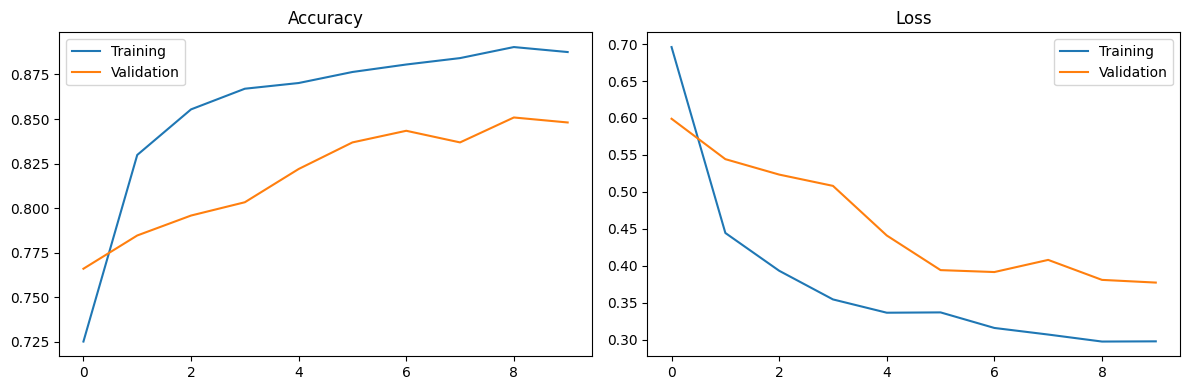

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history["accuracy"], label="Training")
plt.plot(mobilenet_history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history["loss"], label="Training")
plt.plot(mobilenet_history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 13. Confusion Matrix and Classification Report

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step


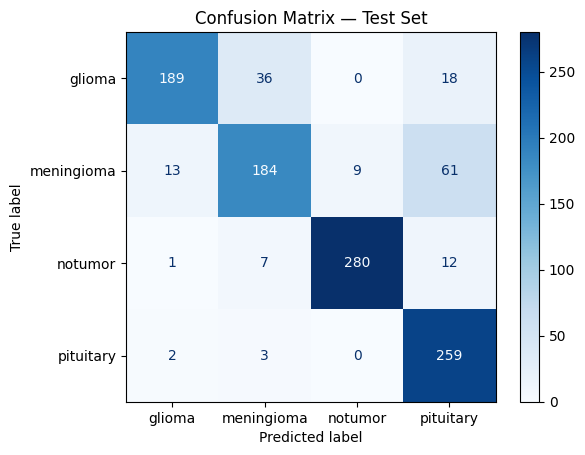

              precision    recall  f1-score   support

      glioma       0.92      0.78      0.84       243
  meningioma       0.80      0.69      0.74       267
     notumor       0.97      0.93      0.95       300
   pituitary       0.74      0.98      0.84       264

    accuracy                           0.85      1074
   macro avg       0.86      0.85      0.84      1074
weighted avg       0.86      0.85      0.85      1074



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])
y_pred_probs = mobilenet_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## 14. Save the Trained Model

In [ ]:
mobilenet_model.save('/content/drive/MyDrive/final_mobilenet_model.keras')
print("Model saved to Google Drive as final_mobilenet_model.keras")

Model saved to Google Drive as final_mobilenet_model.keras
